In [1]:
import pandas as pd
import numpy as np
import json

import matplotlib.pyplot as plt
import seaborn as sns


In [14]:
# json → python dictionary & list → dataframe:
'''gives more control,
lets you inspect raw structure,
useful for nested JSONs later'''

with open(r"C:\Users\kadit\MedicalPlan-Xray\data\raw\data.json")as file:
    data = json.load(file)
    
df = pd.DataFrame(data)
df

,user_id,gender,age,state_tier,occupation_class,salary_bracket,total_income_inr,is_smoker,family_members,medical_plan,annual_expenditure_inr
0,1,Male,19,Tier-2,Low-Risk,Tier-1,203736,0,5,Medium,89149
1,2,Female,20,Tier-1,Low-Risk,Tier-2,527824,0,6,Medium,115346
2,3,Male,46,Tier-2,High-Risk,Tier-1,233707,0,3,High,128494
3,4,Male,66,Tier-1,Low-Risk,Tier-1,330331,0,1,Medium,126971
4,5,Male,42,Tier-1,Low-Risk,Tier-2,879201,0,6,Medium,142701
...,...,...,...,...,...,...,...,...,...,...,...
975,996,Male,40,Tier-3,Medium-Risk,Tier-1,234109,0,3,Low,54431
976,997,Female,53,Tier-1,Low-Risk,Tier-2,1124310,0,6,High,142431
977,998,Male,26,Tier-2,Low-Risk,Tier-1,412093,0,2,Low,48431
978,999,Female,57,Tier-1,Low-Risk,Tier-2,789421,1,4,High,184310


In [15]:
df["user_id"].min()

np.int64(1)

In [16]:
df["user_id"].max()

np.int64(1000)

In [17]:
len(df["user_id"].unique())

980

In [18]:
set(range(1,1001)) - set(df["user_id"]) 

{157,
 158,
 159,
 160,
 161,
 162,
 163,
 164,
 165,
 166,
 167,
 168,
 169,
 170,
 171,
 172,
 173,
 719,
 839,
 929}

In [19]:
df.isnull().sum() # 20 missing values in medical_plan column

user_id                   0
gender                    0
age                       0
state_tier                0
occupation_class          0
salary_bracket            0
total_income_inr          0
is_smoker                 0
family_members            0
medical_plan              0
annual_expenditure_inr    0
dtype: int64

In [20]:
df.duplicated().sum() # no duplicate records

np.int64(0)

In [21]:
# from the above we conclude that Dataset provider removed 20 records entirely.

In [22]:
df.describe(include="object")

C:\Users\kadit\AppData\Local\Temp\ipykernel_27756\702825166.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,gender,state_tier,occupation_class,salary_bracket,medical_plan
count,980,980,980,980,980
unique,9,12,13,16,14
top,Male,Tier-1,Low-Risk,Tier-2,High
freq,486,417,601,411,405


In [23]:
df["gender"].unique() # only 2 unique values, "male" and "female"

<ArrowStringArray>
[      'Male',     'Female',  '  Female ',    '  Male ',     ' Male ',
    ' Male  ',  ' Female  ', '  Female  ',   '  Male  ']
Length: 9, dtype: str

In [24]:

df["state_tier"].unique() # only 3 unique values, "Tier-1", "Tier-2", and "Tier-3"

<ArrowStringArray>
[    'Tier-2',     'Tier-1',     'Tier-3',   ' Tier-1 ', '  Tier-1  ',
  ' Tier-1  ',   ' Tier-2 ',  '  Tier-1 ', '  Tier-2  ',  ' Tier-2  ',
  '  Tier-2 ', '  Tier-3  ']
Length: 12, dtype: str

In [25]:
df["occupation_class"].unique() # only 3 unique values , "Low-Risk", "Medium-Risk", and "High-Risk"

<ArrowStringArray>
[       'Low-Risk',       'High-Risk',     'Medium-Risk',  '  Medium-Risk ',
     ' Low-Risk  ',  ' Medium-Risk  ',    '  High-Risk ',   '  High-Risk  ',
 '  Medium-Risk  ',     '  Low-Risk ',      ' Low-Risk ',    '  Low-Risk  ',
    ' High-Risk  ']
Length: 13, dtype: str

In [26]:
df["salary_bracket"].unique() # only 4 unique values, "Tier-1", "Tier-2", "Tier-3" and "Tier-4"

<ArrowStringArray>
[    'Tier-1',     'Tier-2',     'Tier-4',     'Tier-3',   ' Tier-4 ',
  '  Tier-1 ', '  Tier-2  ', '  Tier-1  ',   ' Tier-1 ',  '  Tier-2 ',
   ' Tier-2 ',  ' Tier-2  ',  ' Tier-1  ',  ' Tier-3  ',  '  Tier-4 ',
 '  Tier-4  ']
Length: 16, dtype: str

In [27]:
df["medical_plan"].unique() # only 3 unique values, "High", "Medium", and "Low"

<ArrowStringArray>
[    'Medium',       'High',        'Low',      ' Low ', '  Medium  ',
     ' High ',    ' High  ',   ' Medium ',    '  High ',  '  Medium ',
  ' Medium  ',   '  High  ',     '  Low ',    '  Low  ']
Length: 14, dtype: str

In [28]:
df["medical_plan"].value_counts()

medical_plan
High          405
Medium        397
Low           151
 High           5
  High          5
  Medium        3
  Medium        3
 Medium         3
 Low            2
 High           2
 Medium         1
  High          1
  Low           1
  Low           1
Name: count, dtype: int64

In [ ]:
# Problem 1. Therefore from above we get that the issue is of "Inconsistent Categorical Data" , as there are unwanted spaces which pandas is treating unique as well.

In [29]:
df["gender"] = df["gender"].str.strip()
df["state_tier"] = df["state_tier"].str.strip()
df["occupation_class"] = df["occupation_class"].str.strip()
df["salary_bracket"] = df["salary_bracket"].str.strip()
df["medical_plan"] = df["medical_plan"].str.strip()

In [30]:
df["gender"].unique()

<ArrowStringArray>
['Male', 'Female']
Length: 2, dtype: str

In [31]:
df["state_tier"].unique()

<ArrowStringArray>
['Tier-2', 'Tier-1', 'Tier-3']
Length: 3, dtype: str

In [33]:
df["occupation_class"].unique()

<ArrowStringArray>
['Low-Risk', 'High-Risk', 'Medium-Risk']
Length: 3, dtype: str

In [34]:
df["salary_bracket"].unique()

<ArrowStringArray>
['Tier-1', 'Tier-2', 'Tier-4', 'Tier-3']
Length: 4, dtype: str

In [35]:
df["medical_plan"].unique()

<ArrowStringArray>
['Medium', 'High', 'Low']
Length: 3, dtype: str

In [36]:
df.describe(include="object")

C:\Users\kadit\AppData\Local\Temp\ipykernel_27756\702825166.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,gender,state_tier,occupation_class,salary_bracket,medical_plan
count,980,980,980,980,980
unique,2,3,3,4,3
top,Male,Tier-1,Low-Risk,Tier-2,High
freq,496,425,611,419,418


In [37]:
# UNDERSTANING TARGET VARIABLE (MEDICAL PLAN):

df["medical_plan"].value_counts(normalize=True) * 100

#High and Medium are dominant
#Low is underrepresented

medical_plan
High      42.653061
Medium    41.530612
Low       15.816327
Name: proportion, dtype: float64

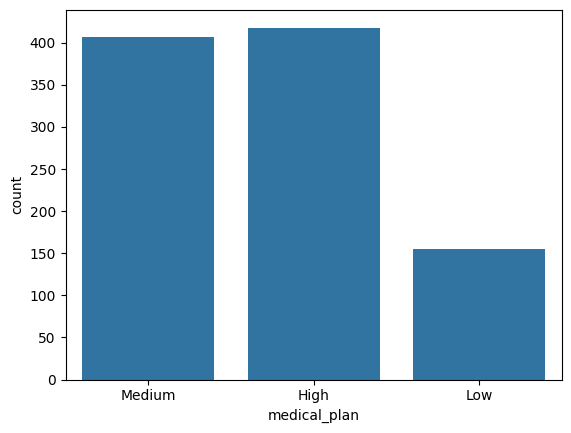

In [38]:
sns.countplot(data=df, x="medical_plan")
plt.show()

# A previous plot wasn't cleared. As a result, the new plot is being drawn on top of the old one, causing them to overlap and look messy. To fix this, we can use plt.clf() to clear the current figure before plotting the new one. This will ensure that only the new plot is displayed without any interference from the previous one.

In [39]:
df["medical_plan"].head(10)

0    Medium
1    Medium
2      High
3    Medium
4    Medium
5      High
6    Medium
7      High
8      High
9      High
Name: medical_plan, dtype: str

In [40]:
# Final validation after cleaning

df.info()

df.describe(include="all")

<class 'pandas.DataFrame'>
RangeIndex: 980 entries, 0 to 979
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   user_id                 980 non-null    int64
 1   gender                  980 non-null    str  
 2   age                     980 non-null    int64
 3   state_tier              980 non-null    str  
 4   occupation_class        980 non-null    str  
 5   salary_bracket          980 non-null    str  
 6   total_income_inr        980 non-null    int64
 7   is_smoker               980 non-null    int64
 8   family_members          980 non-null    int64
 9   medical_plan            980 non-null    str  
 10  annual_expenditure_inr  980 non-null    int64
dtypes: int64(6), str(5)
memory usage: 114.2 KB


,user_id,gender,age,state_tier,occupation_class,salary_bracket,total_income_inr,is_smoker,family_members,medical_plan,annual_expenditure_inr
count,980.000000,980,980.000000,980,980,980,9.800000e+02,980.000000,980.000000,980,980.000000
unique,NaN,2,NaN,3,3,4,NaN,NaN,NaN,3,NaN
top,NaN,Male,NaN,Tier-1,Low-Risk,Tier-2,NaN,NaN,NaN,High,NaN
freq,NaN,496,NaN,425,611,419,NaN,NaN,NaN,418,NaN
mean,505.314286,NaN,45.778571,NaN,NaN,NaN,9.241866e+05,0.213265,3.527551,NaN,134662.093878
std,287.731196,NaN,16.279509,NaN,NaN,NaN,8.652394e+05,0.409823,1.709869,NaN,65517.903020
min,1.000000,NaN,18.000000,NaN,NaN,NaN,1.519340e+05,0.000000,1.000000,NaN,5000.000000
25%,262.750000,NaN,32.000000,NaN,NaN,NaN,4.117075e+05,0.000000,2.000000,NaN,84310.000000
50%,507.500000,NaN,45.000000,NaN,NaN,NaN,7.894210e+05,0.000000,3.500000,NaN,124310.000000
75%,753.250000,NaN,60.000000,NaN,NaN,NaN,1.124310e+06,0.000000,5.000000,NaN,184096.750000


In [41]:
df.to_csv("../data/processed/clean_data.csv", index=False)

# Cleaning Summary

- Missing Values: 0
- Duplicate Rows: 0
- Missing User IDs Investigated
- Inconsistent categorical values corrected
- Leading/trailing spaces removed
- Dataset validated and saved

Final Dataset Shape:
980 Rows × 11 Columns